Dataset:


,Age,AnnualIncome,SpendingScore
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
5,22,17,76
6,35,18,6
7,23,18,94
8,64,19,3
9,30,19,72


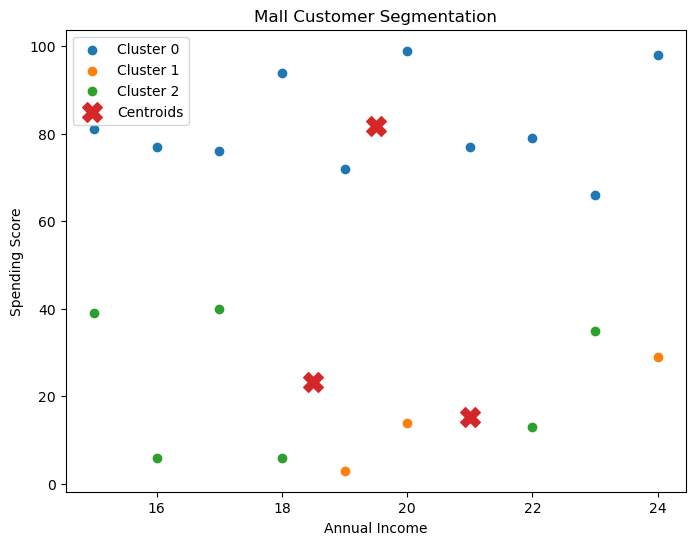


Cluster Centroids:


,Age,AnnualIncome,SpendingScore
0,25.50,19.5,81.900000
1,60.25,21.0,15.250000
2,29.50,18.5,23.166667


In [1]:
# Mall Customer Segmentation using K-Means

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ---------------------------------------------------
# Step 1: Create Dataset
# ---------------------------------------------------

data = {
    "Age": [19, 21, 20, 23, 31, 22, 35, 23, 64, 30,
            67, 35, 58, 24, 37, 22, 35, 20, 52, 35],
    
    "AnnualIncome": [15, 15, 16, 16, 17, 17, 18, 18, 19, 19,
                     20, 20, 21, 21, 22, 22, 23, 23, 24, 24],
    
    "SpendingScore": [39, 81, 6, 77, 40, 76, 6, 94, 3, 72,
                      14, 99, 15, 77, 13, 79, 35, 66, 29, 98]
}

df = pd.DataFrame(data)

print("Dataset:")
display(df)

# ---------------------------------------------------
# Step 2: Apply KMeans Clustering
# ---------------------------------------------------

X = df[["Age", "AnnualIncome", "SpendingScore"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

# ---------------------------------------------------
# Step 3: Plot Clusters
# ---------------------------------------------------

plt.figure(figsize=(8,6))

for cluster in range(3):
    cluster_data = df[df["Cluster"] == cluster]
    plt.scatter(cluster_data["AnnualIncome"],
                cluster_data["SpendingScore"],
                label=f"Cluster {cluster}")

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:,1], centroids[:,2],
            marker='X', s=200, label="Centroids")

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Mall Customer Segmentation")
plt.legend()
plt.show()

# ---------------------------------------------------
# Step 4: Display Centroids
# ---------------------------------------------------

centroid_df = pd.DataFrame(
    centroids,
    columns=["Age", "AnnualIncome", "SpendingScore"]
)

print("\nCluster Centroids:")
display(centroid_df)